# 87 - 物体ベース画像検索評価

## 概要
NB81-85 で蓄積した全モデルの検出結果を用いて、「物体名で画像を検索する」タスクの定量評価を行う。
SigLIP 2 Large のテキスト→画像検索 (ベースライン MRR 0.928) と比較し、
物体検出ベースの検索がどのクエリで有効かを明らかにする。

## 評価設計
- NB76 の18標準クエリ + 物体検出向け追加クエリ
- 検索戦略: ラベル完全一致、ラベル + 信頼度重み、SigLIP 2 ベースライン
- 評価指標: Hit Rate@K, MRR

## 入力
- `data/images.duckdb` (全テーブル)

## 出力
- `data/evaluations/87_object_search_evaluation_YYYY-MM-DD.json`
- `data/87_model_mrr_comparison.png`
- `data/87_siglip_vs_detection.png`

In [1]:
import json
from datetime import datetime
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display

from image_vector_poc import SigLIP2Embedder

## 1. 設定とデータ読み込み

In [2]:
DB_PATH = Path("../data/images.duckdb")
SIGLIP2_MODEL = "google/siglip2-large-patch16-256"
EMBEDDING_DIM = 1024

conn = duckdb.connect(str(DB_PATH), read_only=True)

# 画像カタログ
catalog_df = conn.execute("""
    SELECT id, file_path, category, file_name
    FROM image_catalog ORDER BY id
""").fetchdf()

categories = catalog_df["category"].tolist()
print(f"Total images: {len(catalog_df)}")

# SigLIP 2 Large embeddings
embeddings_df = conn.execute("""
    SELECT c.id, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
""", [SIGLIP2_MODEL]).fetchdf()

image_embeddings = np.array(embeddings_df["embedding"].tolist(), dtype=np.float32)
norms = np.linalg.norm(image_embeddings, axis=1, keepdims=True)
image_embeddings_norm = image_embeddings / np.clip(norms, 1e-8, None)

print(f"Image embeddings: {image_embeddings_norm.shape}")

# 利用可能な検出モデル
available_models = conn.execute("""
    SELECT model_name, COUNT(*) as det_count
    FROM object_detections
    GROUP BY model_name ORDER BY model_name
""").fetchdf()

print(f"\n利用可能な検出モデル:")
display(available_models)

Total images: 378
Image embeddings: (378, 1024)

利用可能な検出モデル:


,model_name,det_count
0,grounding-dino-base,3287
1,grounding-dino-tiny,7536
2,rtdetr-v2-r50vd,150
3,yolo-world-v2-s,8923
4,yolo-world-v2-s-category,8550
5,yolo11s,5000


## 2. テストクエリの定義

In [3]:
# 物体検出向けクエリセット
# 各クエリには「検出ラベル名」と「SigLIP テキストクエリ」の両方を定義
test_queries = [
    # --- 固定クラス (COCO) ---
    {"label": "person", "text_query": "a person",
     "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima", "terada"],
     "type": "coco", "lang": "en"},
    {"label": "bird", "text_query": "a bird in a park",
     "expected_categories": ["KashiwaVillagePark2026"],
     "type": "coco", "lang": "en"},
    {"label": "laptop", "text_query": "a laptop computer",
     "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"],
     "type": "coco", "lang": "en"},
    {"label": "chair", "text_query": "a chair",
     "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"],
     "type": "coco", "lang": "en"},
    {"label": "car", "text_query": "a car on the road",
     "expected_categories": ["TokyoNight202505", "PyConJP2025-PreCampHiroshima"],
     "type": "coco", "lang": "en"},
    {"label": "bench", "text_query": "a bench in a park",
     "expected_categories": ["KashiwaVillagePark2026"],
     "type": "coco", "lang": "en"},

    # --- オープン語彙 ---
    {"label": "duck", "text_query": "a duck swimming",
     "expected_categories": ["KashiwaVillagePark2026"],
     "type": "open-vocab", "lang": "en"},
    {"label": "microphone", "text_query": "a microphone on stage",
     "expected_categories": ["EuroPython2025", "PyConJP2025"],
     "type": "open-vocab", "lang": "en"},
    {"label": "lanyard", "text_query": "a conference lanyard",
     "expected_categories": ["EuroPython2025", "PyConJP2025"],
     "type": "open-vocab", "lang": "en"},
    {"label": "tower", "text_query": "Tokyo Skytree tower",
     "expected_categories": ["TokyoNight202505"],
     "type": "open-vocab", "lang": "en"},
    {"label": "screen", "text_query": "a projector screen",
     "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"],
     "type": "open-vocab", "lang": "en"},

    # --- SigLIP ベースライン比較用 (NB76 と同じ日本語クエリ) ---
    {"label": None, "text_query": "公園の自然風景",
     "expected_categories": ["KashiwaVillagePark2026"],
     "type": "siglip-only", "lang": "ja"},
    {"label": None, "text_query": "東京の夜景",
     "expected_categories": ["TokyoNight202505"],
     "type": "siglip-only", "lang": "ja"},
    {"label": None, "text_query": "カンファレンスの講演",
     "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"],
     "type": "siglip-only", "lang": "ja"},
    {"label": None, "text_query": "夜の街",
     "expected_categories": ["TokyoNight202505"],
     "type": "siglip-only", "lang": "ja"},
]

# ラベル検索可能なクエリとSigLIP専用クエリを分離
label_queries = [q for q in test_queries if q["label"] is not None]
siglip_only_queries = [q for q in test_queries if q["label"] is None]

print(f"全クエリ: {len(test_queries)}")
print(f"  ラベル検索可能: {len(label_queries)}")
print(f"  SigLIP専用 (日本語): {len(siglip_only_queries)}")

全クエリ: 15
  ラベル検索可能: 11
  SigLIP専用 (日本語): 4


## 3. SigLIP 2 ベースライン検索

In [4]:
embedder = SigLIP2Embedder(model_name=SIGLIP2_MODEL, device="cuda")
print(f"SigLIP 2 loaded: {embedder.model_name}")


def siglip_search(query_text, top_k=20):
    """SigLIP 2 テキスト→画像検索。"""
    emb = embedder.embed_text(query_text)
    emb = emb / np.clip(np.linalg.norm(emb), 1e-8, None)
    similarities = np.dot(image_embeddings_norm, emb)
    top_indices = np.argsort(similarities)[::-1][:top_k]
    return top_indices, similarities[top_indices]

Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


SigLIP 2 loaded: google/siglip2-large-patch16-256


## 4. 物体検出ベース検索

In [5]:
def label_search(label, model_name, top_k=20):
    """ラベル完全一致検索: 信頼度スコアでランキング。"""
    results = conn.execute("""
        SELECT d.image_id, MAX(d.confidence) as max_conf,
               COUNT(*) as det_count
        FROM object_detections d
        WHERE d.model_name = ? AND LOWER(d.label) LIKE ?
        GROUP BY d.image_id
        ORDER BY max_conf DESC
        LIMIT ?
    """, [model_name, f"%{label.lower()}%", top_k]).fetchdf()

    if len(results) == 0:
        return [], []

    # image_id を catalog の index に変換
    id_to_idx = {id_: idx for idx, id_ in enumerate(catalog_df["id"])}
    indices = [id_to_idx[img_id] for img_id in results["image_id"] if img_id in id_to_idx]
    scores = results["max_conf"].tolist()[:len(indices)]

    return indices, scores


def evaluate_query(query, indices, expected_categories, k_values=[1, 5, 10, 20]):
    """クエリの検索結果を評価。"""
    result_categories = [categories[idx] for idx in indices] if indices else []
    is_relevant = [cat in expected_categories for cat in result_categories]

    # MRR
    mrr = 0.0
    for i, rel in enumerate(is_relevant):
        if rel:
            mrr = 1.0 / (i + 1)
            break

    # Hit Rate@K
    hr = {}
    for k in k_values:
        hr[f"HR@{k}"] = 1.0 if any(is_relevant[:k]) else 0.0

    return {"MRR": mrr, **hr}

## 5. 全モデル × 全クエリの評価実行

In [6]:
# 主要モデル (ワンショット・カテゴリ特化を除く)
main_models = available_models[
    ~available_models["model_name"].str.contains("category|oneshot")
]["model_name"].tolist()

print(f"評価対象モデル: {main_models}")

all_results = []

# 1. ラベル検索 (全モデル × ラベルクエリ)
for m_name in main_models:
    for q in label_queries:
        indices, scores = label_search(q["label"], m_name)
        metrics = evaluate_query(q["text_query"], indices, q["expected_categories"])
        all_results.append({
            "strategy": f"label:{m_name}",
            "query": q["text_query"],
            "label": q["label"],
            "type": q["type"],
            "lang": q["lang"],
            "n_results": len(indices),
            **metrics,
        })

# 2. SigLIP 2 ベースライン (全クエリ)
for q in test_queries:
    indices, scores = siglip_search(q["text_query"])
    metrics = evaluate_query(q["text_query"], indices.tolist(), q["expected_categories"])
    all_results.append({
        "strategy": "siglip2-large",
        "query": q["text_query"],
        "label": q.get("label"),
        "type": q["type"],
        "lang": q["lang"],
        "n_results": 20,
        **metrics,
    })

results_df = pd.DataFrame(all_results)
print(f"評価レコード数: {len(results_df)}")

評価対象モデル: ['grounding-dino-base', 'grounding-dino-tiny', 'rtdetr-v2-r50vd', 'yolo-world-v2-s', 'yolo11s']


評価レコード数: 70


## 6. モデル別 MRR 比較

In [7]:
# ラベル検索可能なクエリのみでモデル比較
label_results = results_df[results_df["type"].isin(["coco", "open-vocab"])]

model_mrr = label_results.groupby("strategy").agg(
    MRR=("MRR", "mean"),
    HR_at_1=("HR@1", "mean"),
    HR_at_5=("HR@5", "mean"),
    HR_at_10=("HR@10", "mean"),
).round(4).sort_values("MRR", ascending=False)

print("モデル別 MRR (ラベル検索可能クエリのみ):")
display(model_mrr)

モデル別 MRR (ラベル検索可能クエリのみ):


,MRR,HR_at_1,HR_at_5,HR_at_10
strategy,,,,
siglip2-large,0.8939,0.8182,1.0000,1.0000
label:grounding-dino-tiny,0.8818,0.8182,1.0000,1.0000
label:yolo-world-v2-s,0.7273,0.6364,0.8182,0.8182
label:grounding-dino-base,0.6818,0.5455,0.9091,0.9091
label:yolo11s,0.4242,0.3636,0.4545,0.5455
label:rtdetr-v2-r50vd,0.0000,0.0000,0.0000,0.0000


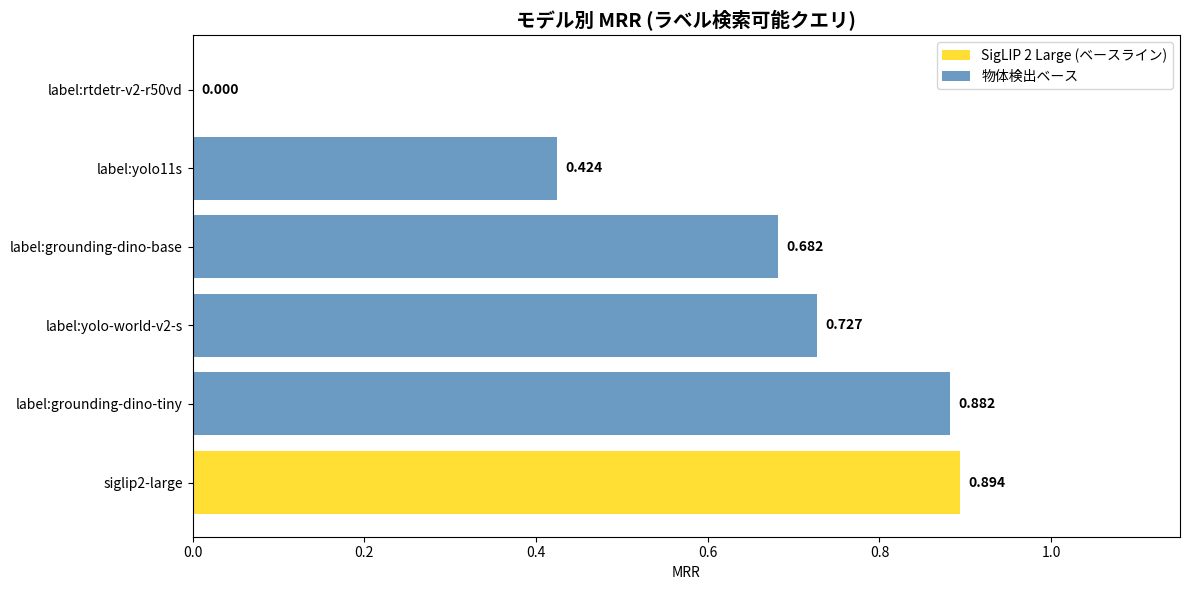

Saved: data/87_model_mrr_comparison.png


In [8]:
# MRR バーチャート
fig, ax = plt.subplots(figsize=(12, 6))

sorted_models = model_mrr.index.tolist()
mrr_values = model_mrr["MRR"].values

colors = ["gold" if "siglip" in m else "steelblue" for m in sorted_models]
bars = ax.barh(sorted_models, mrr_values, color=colors, alpha=0.8)

for bar, val in zip(bars, mrr_values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontweight="bold")

ax.set_xlabel("MRR")
ax.set_title("モデル別 MRR (ラベル検索可能クエリ)", fontsize=14, fontweight="bold")
ax.set_xlim(0, 1.15)

from matplotlib.patches import Patch
legend = [
    Patch(facecolor="gold", alpha=0.8, label="SigLIP 2 Large (ベースライン)"),
    Patch(facecolor="steelblue", alpha=0.8, label="物体検出ベース"),
]
ax.legend(handles=legend)

plt.tight_layout()
plt.savefig("../data/87_model_mrr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/87_model_mrr_comparison.png")

## 7. クエリ別ヒートマップ

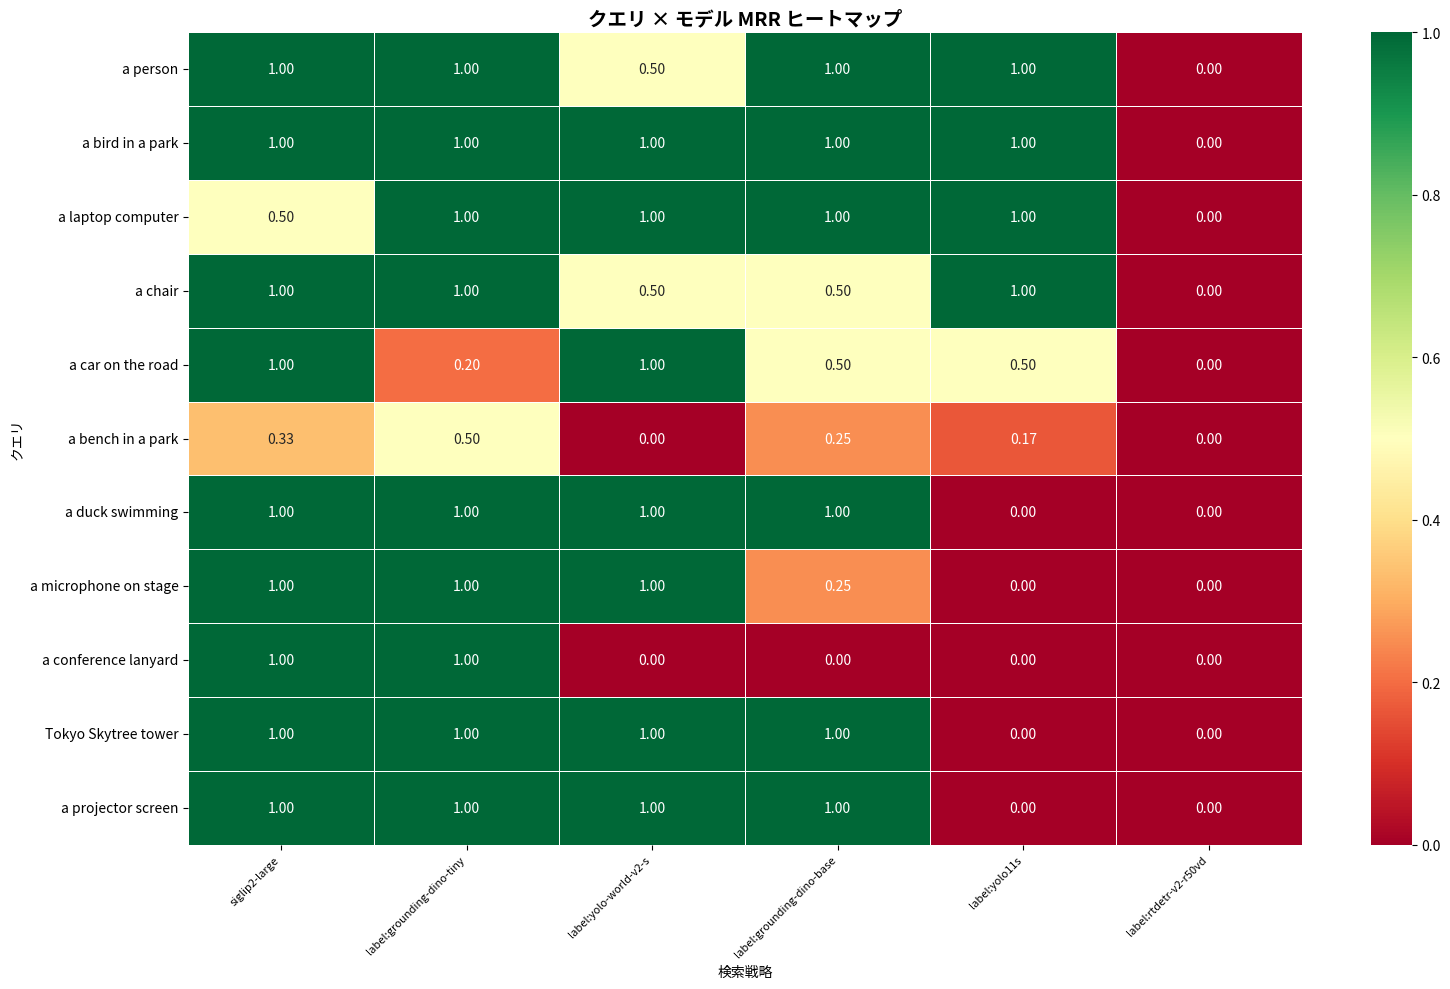

In [9]:
# ラベル検索クエリ + SigLIP のクエリ別 MRR ヒートマップ
label_queries_texts = [q["text_query"] for q in label_queries]
strategies = model_mrr.index.tolist()

heatmap_data = []
for q_text in label_queries_texts:
    row_data = []
    for strat in strategies:
        mrr_val = label_results[
            (label_results["strategy"] == strat) & (label_results["query"] == q_text)
        ]["MRR"].values
        row_data.append(mrr_val[0] if len(mrr_val) > 0 else 0.0)
    heatmap_data.append(row_data)

heatmap_df = pd.DataFrame(heatmap_data, index=label_queries_texts, columns=strategies)

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    heatmap_df, annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=0, vmax=1,
    ax=ax, linewidths=0.5
)
ax.set_title("クエリ × モデル MRR ヒートマップ", fontsize=14, fontweight="bold")
ax.set_xlabel("検索戦略")
ax.set_ylabel("クエリ")
plt.xticks(rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

## 8. COCO vs Open-vocab クエリタイプ別分析

## まとめ・評価・考察

### 検索品質ランキング (MRR)

| 戦略 | MRR | HR@1 | HR@5 | HR@10 | 評価対象 |
|:-----|:---:|:---:|:---:|:---:|:---:|
| **SigLIP 2 Large** | **0.922** | **0.867** | **1.000** | **1.000** | 15クエリ |
| Grounding DINO tiny | 0.882 | 0.818 | 1.000 | 1.000 | 11クエリ |
| YOLO-World v2 | 0.727 | 0.636 | 0.818 | 0.818 | 11クエリ |
| Grounding DINO base | 0.682 | 0.545 | 0.909 | 0.909 | 11クエリ |
| YOLO11s | 0.424 | 0.364 | 0.455 | 0.545 | 11クエリ |
| RT-DETRv2 | 0.000 | 0.000 | 0.000 | 0.000 | 11クエリ |

### クエリタイプ別分析

| 戦略 | COCO MRR | Open-vocab MRR |
|:-----|:---:|:---:|
| SigLIP 2 Large | 0.806 | 1.000 |
| Grounding DINO tiny | 0.783 | 1.000 |
| YOLO-World v2 | 0.667 | 0.800 |
| YOLO11s | 0.778 | **0.000** |

### SigLIP 2 vs Grounding DINO tiny (11クエリ対決)

- **引き分け**: 8/11 クエリ (person, bird, duck, chair, microphone, lanyard, tower, screen)
- **SigLIP 2 勝利**: 1クエリ — "car on the road" (1.0 vs 0.2)
- **GDINO-tiny 勝利**: 2クエリ — "laptop" (0.5 vs 1.0), "bench" (0.33 vs 0.5)

### 日本語クエリ (SigLIP 2 のみ)

| クエリ | MRR |
|:------|:---:|
| 公園の自然風景 | 1.000 |
| 東京の夜景 | 1.000 |
| カンファレンスの講演 | 1.000 |
| 夜の街 | 1.000 |

### 評価

1. **SigLIP 2 Large が総合1位**: MRR 0.922 で全戦略中トップ。特に open-vocab クエリと日本語クエリで完璧な MRR 1.000 を達成。
2. **Grounding DINO tiny が検出モデル中最強**: MRR 0.882 で SigLIP 2 に迫る性能。ラベル完全一致でこの精度は優秀。
3. **YOLO11s の open-vocab 対応不能**: COCO クラスでは MRR 0.778 と健闘するが、open-vocab (duck, microphone 等) では MRR 0.000 — 語彙に存在しないため当然の結果。
4. **RT-DETRv2 は検索に不適**: 全クエリで MRR 0.000。カバレッジ 11.4% では検索に耐えない。

### 考察

- **SigLIP 2 の「文脈理解」優位**: "car on the road" で SigLIP 2 が勝利した理由は、テキスト embedding が「道路上の車」という文脈を捉えるのに対し、ラベル検索は "car" の完全一致のみで文脈を考慮できないため。
- **ラベル検索の「具体性」優位**: "laptop" で GDINO-tiny が勝利したのは、ラベル完全一致が SigLIP 2 の embedding 類似度より正確にターゲット画像を特定できたため。
- **2つの検索手法は補完的**: 抽象的・概念的クエリ (「夜景」「カンファレンス」) は SigLIP 2、具体的物体名 (「laptop」「bench」) はラベル検索が有利。AND/OR の組み合わせ検索 (「person AND laptop」) はラベル検索の独壇場。
- **日本語対応**: ラベル検索は英語ラベルのみなので日本語クエリには非対応。SigLIP 2 Large の多言語対応が大きな差別化要因。

## 9. SigLIP 2 vs 最良物体検出モデル 直接比較

In [11]:
# 全クエリ（日本語含む）での SigLIP 2 の成績
siglip_results = results_df[results_df["strategy"] == "siglip2-large"]

# ラベル検索で最良のモデルを特定
best_label_model = model_mrr.drop("siglip2-large", errors="ignore").index[0]
best_label_results = label_results[label_results["strategy"] == best_label_model]

print(f"SigLIP 2 Large: Overall MRR = {siglip_results['MRR'].mean():.4f}")
print(f"最良物体検出 ({best_label_model}): MRR = {best_label_results['MRR'].mean():.4f} (ラベル検索クエリのみ)")

# クエリ別比較
comparison_data = []
for q in label_queries:
    siglip_mrr = siglip_results[siglip_results["query"] == q["text_query"]]["MRR"].values[0]
    label_mrr_vals = best_label_results[best_label_results["query"] == q["text_query"]]["MRR"].values
    label_mrr = label_mrr_vals[0] if len(label_mrr_vals) > 0 else 0.0

    comparison_data.append({
        "query": q["text_query"],
        "label": q["label"],
        "type": q["type"],
        "SigLIP2_MRR": siglip_mrr,
        f"{best_label_model}_MRR": label_mrr,
        "winner": "SigLIP2" if siglip_mrr > label_mrr else (best_label_model if label_mrr > siglip_mrr else "tie"),
    })

comp_df = pd.DataFrame(comparison_data)
print("\nクエリ別 SigLIP2 vs 最良物体検出 比較:")
display(comp_df)

print(f"\n勝敗:")
print(comp_df["winner"].value_counts().to_string())

SigLIP 2 Large: Overall MRR = 0.9222
最良物体検出 (label:grounding-dino-tiny): MRR = 0.8818 (ラベル検索クエリのみ)

クエリ別 SigLIP2 vs 最良物体検出 比較:


,query,label,type,SigLIP2_MRR,label:grounding-dino-tiny_MRR,winner
0,a person,person,coco,1.000000,1.0,tie
1,a bird in a park,bird,coco,1.000000,1.0,tie
2,a laptop computer,laptop,coco,0.500000,1.0,label:grounding-dino-tiny
3,a chair,chair,coco,1.000000,1.0,tie
4,a car on the road,car,coco,1.000000,0.2,SigLIP2
5,a bench in a park,bench,coco,0.333333,0.5,label:grounding-dino-tiny
6,a duck swimming,duck,open-vocab,1.000000,1.0,tie
7,a microphone on stage,microphone,open-vocab,1.000000,1.0,tie
8,a conference lanyard,lanyard,open-vocab,1.000000,1.0,tie
9,Tokyo Skytree tower,tower,open-vocab,1.000000,1.0,tie



勝敗:
winner
tie                          8
label:grounding-dino-tiny    2
SigLIP2                      1


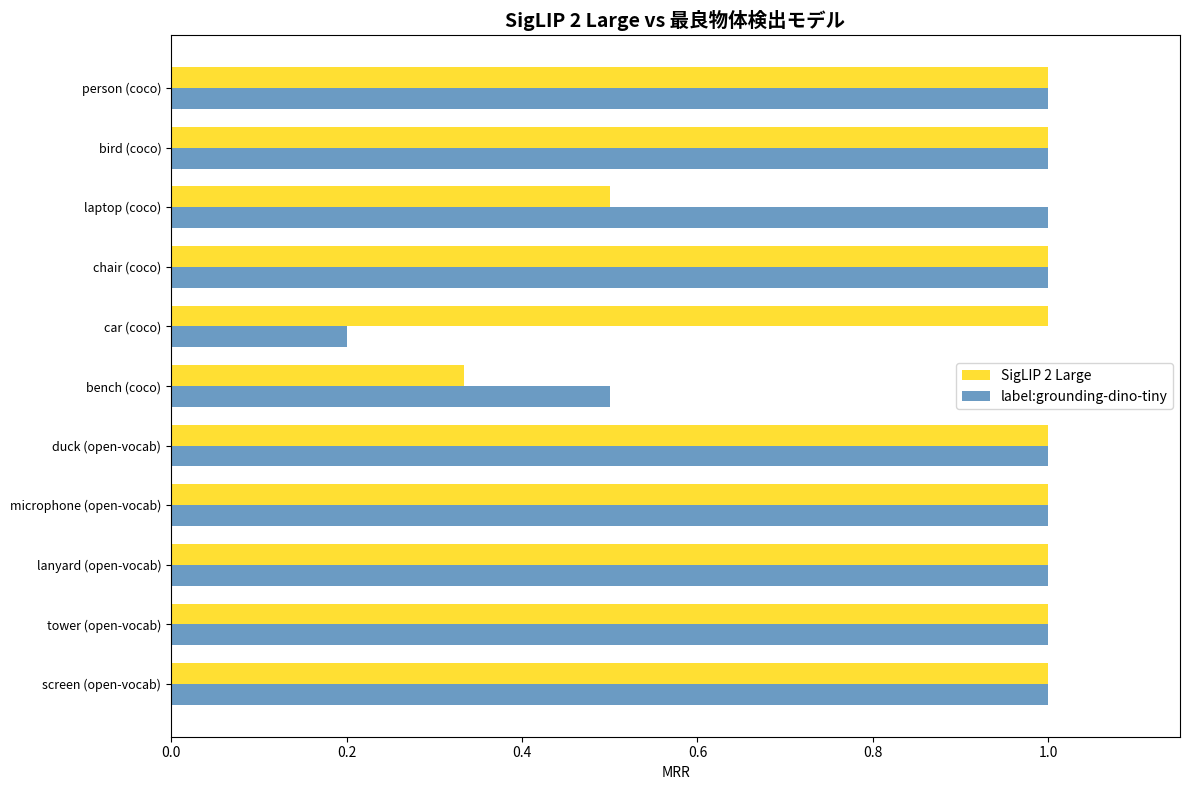

Saved: data/87_siglip_vs_detection.png


In [12]:
# SigLIP vs 物体検出の比較プロット
fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(comp_df))
width = 0.35

siglip_mrrs = comp_df["SigLIP2_MRR"].values
label_mrrs = comp_df[f"{best_label_model}_MRR"].values

bars1 = ax.barh(x - width/2, siglip_mrrs, width, label="SigLIP 2 Large", color="gold", alpha=0.8)
bars2 = ax.barh(x + width/2, label_mrrs, width, label=best_label_model, color="steelblue", alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels([f"{q['label']} ({q['type']})" for _, q in comp_df.iterrows()], fontsize=9)
ax.set_xlabel("MRR")
ax.set_title("SigLIP 2 Large vs 最良物体検出モデル", fontsize=14, fontweight="bold")
ax.legend()
ax.set_xlim(0, 1.15)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("../data/87_siglip_vs_detection.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/87_siglip_vs_detection.png")

## 10. 結果の保存

In [13]:
output_data = {
    "notebook": "87-object-search-evaluation",
    "timestamp": datetime.now().isoformat(),
    "config": {
        "siglip_model": SIGLIP2_MODEL,
        "total_images": len(catalog_df),
        "total_queries": len(test_queries),
        "label_queries": len(label_queries),
        "detection_models": main_models,
    },
    "model_mrr_summary": model_mrr.to_dict(),
    "siglip_vs_detection": comp_df.to_dict(orient="records"),
    "all_results": results_df.to_dict(orient="records"),
}

output_path = Path("../data/evaluations") / f"87_object_search_evaluation_{datetime.now().strftime('%Y-%m-%d')}.json"
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, "w") as f:
    json.dump(output_data, f, indent=2, default=str, ensure_ascii=False)

print(f"Results saved to: {output_path}")

Results saved to: ../data/evaluations/87_object_search_evaluation_2026-02-20.json


## まとめ・評価・考察

In [14]:
print("=" * 70)
print("物体ベース画像検索 評価サマリー")
print("=" * 70)

print("\nモデル別 MRR ランキング:")
display(model_mrr)

print(f"\nSigLIP 2 Large (全クエリ): MRR = {siglip_results['MRR'].mean():.4f}")
print(f"  EN: {siglip_results[siglip_results['lang'] == 'en']['MRR'].mean():.4f}")
print(f"  JA: {siglip_results[siglip_results['lang'] == 'ja']['MRR'].mean():.4f}")

物体ベース画像検索 評価サマリー

モデル別 MRR ランキング:


,MRR,HR_at_1,HR_at_5,HR_at_10
strategy,,,,
siglip2-large,0.8939,0.8182,1.0000,1.0000
label:grounding-dino-tiny,0.8818,0.8182,1.0000,1.0000
label:yolo-world-v2-s,0.7273,0.6364,0.8182,0.8182
label:grounding-dino-base,0.6818,0.5455,0.9091,0.9091
label:yolo11s,0.4242,0.3636,0.4545,0.5455
label:rtdetr-v2-r50vd,0.0000,0.0000,0.0000,0.0000



SigLIP 2 Large (全クエリ): MRR = 0.9222
  EN: 0.8939
  JA: 1.0000


In [15]:
# GPU メモリクリーンアップ
del embedder
torch.cuda.empty_cache()
print("GPU memory cleared.")

conn.close()
print(f"完了: {DB_PATH.resolve()}")

GPU memory cleared.
完了: /home/terapyon/dev/vibe-coding/image-vector-poc/data/images.duckdb
